In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import yaml
import hashlib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.xgb_train import train_xgboost
from src.eval.metrics import confusion_at_threshold
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat" # Tag dataset

vnat_old = pd.read_parquet(paths.data_processed / "vnat" / "features_trainable.parquet")

split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()

vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()
logger.info(f"VNAT features shape: {vnat_feats.shape}")

logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()

iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()
logger.info(f"ISCX features shape: {iscx_feats.shape}")

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)

df_all["split"] = df_all["split"].replace({
    "iscx_train": "train",
    "iscx_val": "val",
    "iscx_test": "test"
})

# --- MANUAL OVERRIDE: Fix Voipbuster Split ---
# Move 'vpn_vpn_voipbuster1a.pcap' to TRAIN so the model can learn it.
# Move 'vpn_vpn_voipbuster1b.pcap' to TEST for evaluation.
vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"

mask_vb_train = df_all["capture_id"] == vb_train_cap
if mask_vb_train.sum() > 0:
    logger.info(f"Moving {mask_vb_train.sum()} flows of {vb_train_cap} to TRAIN.")
    df_all.loc[mask_vb_train, "split"] = "train"

mask_vb_test = df_all["capture_id"] == vb_test_cap
if mask_vb_test.sum() > 0:
    logger.info(f"Moving {mask_vb_test.sum()} flows of {vb_test_cap} to TEST.")
    df_all.loc[mask_vb_test, "split"] = "test"

print("Splits:", df_all["split"].value_counts())

# 4.5 Fit and Save Feature Pipeline
logger.info("Fitting and saving new FeaturePipeline...")
train_df = df_all[df_all["split"] == "train"]
pipeline = FeaturePipeline()

# Add provenance metadata
provenance = {
    "fit_on": "vnat_iscx_joint/train",
    "n_samples": len(train_df),
    "capture_ids_hash": hashlib.sha256(",".join(sorted(train_df["capture_id"].unique())).encode("utf-8")).hexdigest()
}

pipeline.fit(train_df, fit_provenance=provenance)

feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
feat_hash = feature_config_hash_text(features_yaml)
pipeline.save(feature_art, feature_config_hash=feat_hash)
logger.info(f"Pipeline saved. Model features: {len(pipeline.model_feature_names())}")

# 5. Train XGBoost
xgb_yaml = paths.configs_dir / "xgb.yaml"
res = train_xgboost(paths=paths, xgb_yaml=xgb_yaml, df=df_all)

print("\n--- Training Complete ---")
print_metrics_summary(res.metrics)

# 5.5 Calibrate (Standardized Path)
logger.info("Calibrating probabilities...")
df_preds = pd.read_parquet(res.preds_path)

# Fit on VAL split using the consistent wrapper
calibrator = fit_calibrator_from_df(
    df_preds,
    prob_col="p_raw",
    label_col="label",
    split_col="split",
    fit_split="val",
    method="platt"
)

# Apply to all splits
df_preds["p_calib"] = calibrator.predict(df_preds["p_raw"].to_numpy())
df_preds.to_parquet(res.preds_path, index=False)
logger.info("Calibration complete. p_calib added to preds.parquet")

# 6. Evaluate Voipbuster specifically
model_path = res.model_path
booster = xgb.Booster()
booster.load_model(str(model_path))

# We need to re-fit the pipeline on the NEW features (since columns changed)
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline = FeaturePipeline.load(feature_art)
feat_cols = pipeline.model_feature_names()

print(f"\nModel uses {len(feat_cols)} features.")
print("Top features:", feat_cols[:5])

# Identify Voipbuster in Test
test_df = df_all[df_all["split"] == "test"].copy()
vb_mask = test_df["capture_id"].str.contains("voipbuster")
vb_df = test_df[vb_mask].copy()

if len(vb_df) > 0:
    X_all_transformed = pipeline.transform(df_all)
    X_vb = X_all_transformed.loc[vb_df.index, feat_cols].to_numpy(dtype=float)

    # Standard Inference: Booster + DMatrix
    p_vb_raw = booster.predict(xgb.DMatrix(X_vb, feature_names=feat_cols))

    # Apply Calibration
    p_vb_calib = calibrator.predict(p_vb_raw)

    # Get threshold
    firewall_pol = res.metrics.get("firewall_policy", {})
    thr = float(firewall_pol.get("threshold", 0.5))

    y_vb = vb_df["label"].to_numpy(dtype=int)
    yhat_vb = (p_vb_calib >= thr).astype(int)

    acc = (yhat_vb == y_vb).mean()
    recall = (yhat_vb[y_vb==1] == 1).mean() if (y_vb==1).sum() > 0 else 0.0

    print(f"\nVoipbuster Results (N={len(vb_df)}):")
    print(f"Mean Prob (Raw):   {p_vb_raw.mean():.4f}")
    print(f"Mean Prob (Calib): {p_vb_calib.mean():.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall:   {recall:.4f}")
else:
    print("\nVoipbuster not found in test set (maybe it was in train/val after split merge?)")
    # Check where it went
    vb_all = df_all[df_all["capture_id"].str.contains("voipbuster")]
    print("Voipbuster split distribution:", vb_all["split"].value_counts())


2026-02-24 20:43:17 | INFO | ai-vpn-firewall | Re-extracting VNAT features...
2026-02-24 20:44:03 | INFO | ai-vpn-firewall | VNAT features shape: (8107, 72)
2026-02-24 20:44:03 | INFO | ai-vpn-firewall | Re-extracting ISCX features...
2026-02-24 20:44:29 | INFO | ai-vpn-firewall | ISCX features shape: (4882, 72)
2026-02-24 20:44:29 | INFO | ai-vpn-firewall | Moving 58 flows of vpn_vpn_voipbuster1a.pcap to TRAIN.
2026-02-24 20:44:29 | INFO | ai-vpn-firewall | Moving 54 flows of vpn_vpn_voipbuster1b.pcap to TEST.
Splits: split
train    11364
val       1078
test       547
Name: count, dtype: int64
2026-02-24 20:44:29 | INFO | ai-vpn-firewall | Fitting and saving new FeaturePipeline...
2026-02-24 20:44:29 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 67
DEBUG mean/std (first 5):
[ 0.  0.  0.  0. -0.]
[1. 1. 1. 1. 1.]
[0]	train-logloss:0.65108	train-auc:0.98524	train-aucpr:0.92878	val-logloss:0.66344	val-auc:0.88598	val-aucpr:0.84643
[100]	train-logloss:0.01901	train-auc:0.9999


--- Generating Plots ---


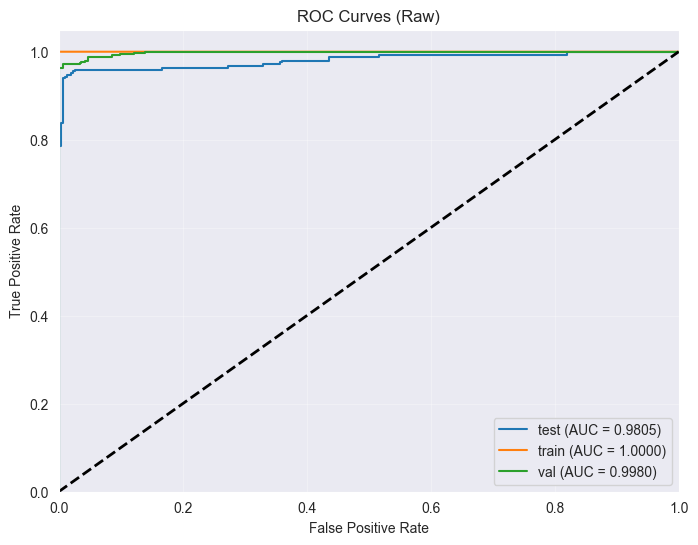

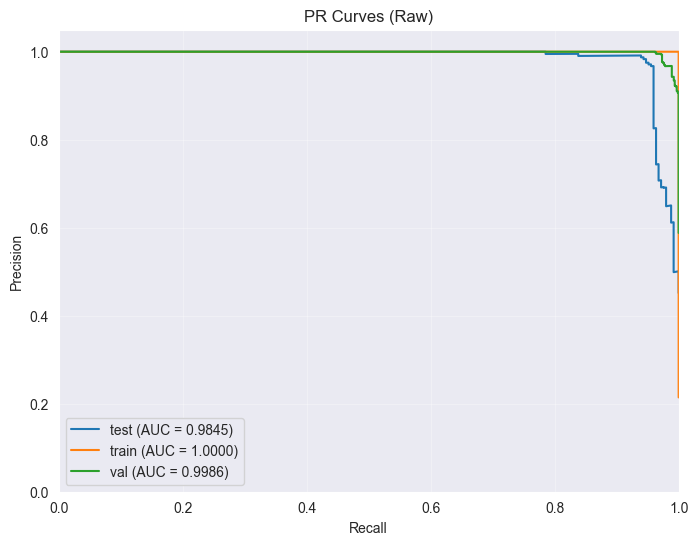

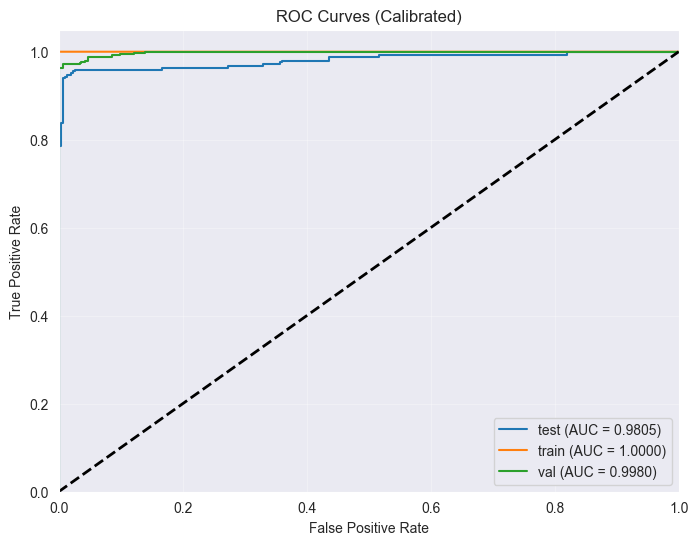

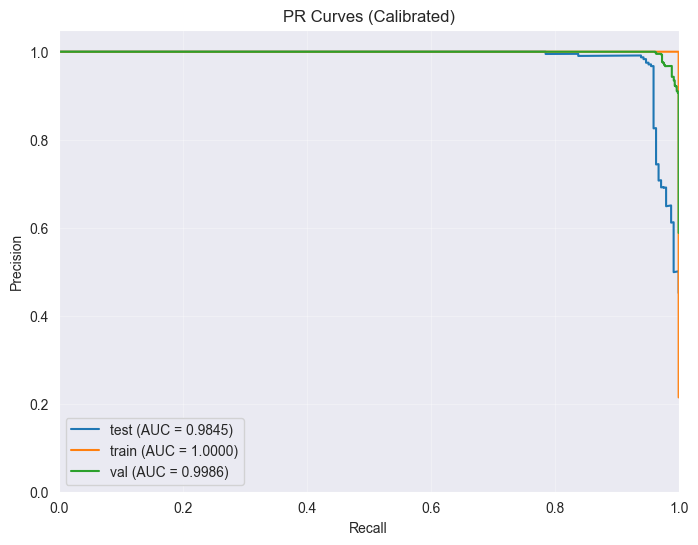

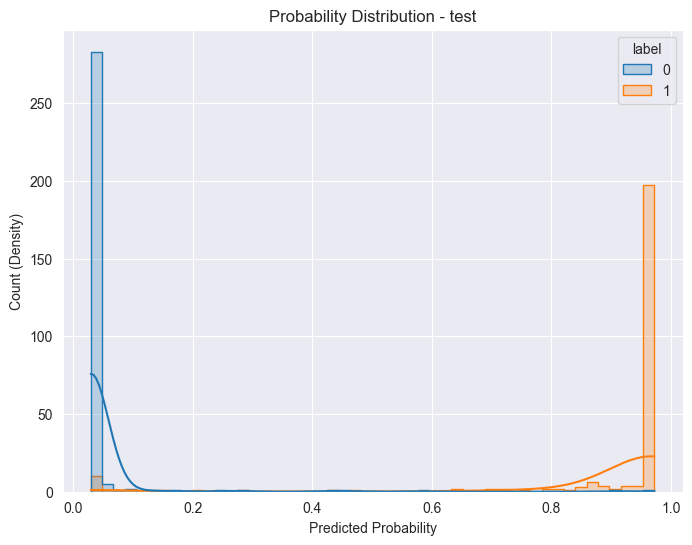

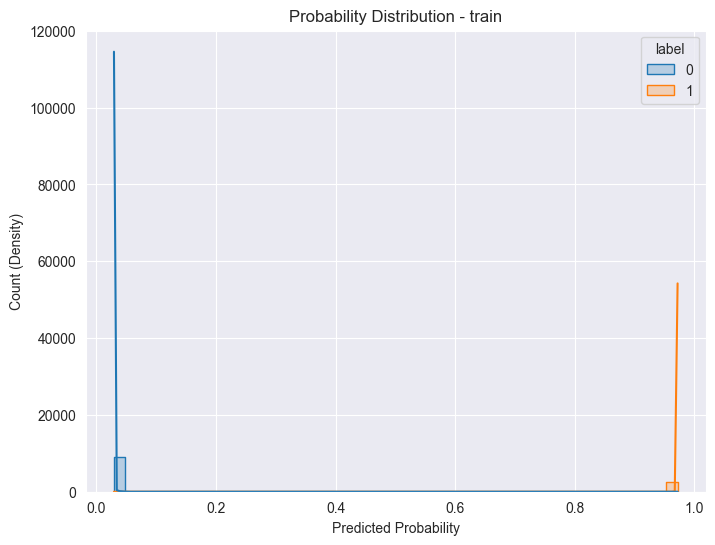

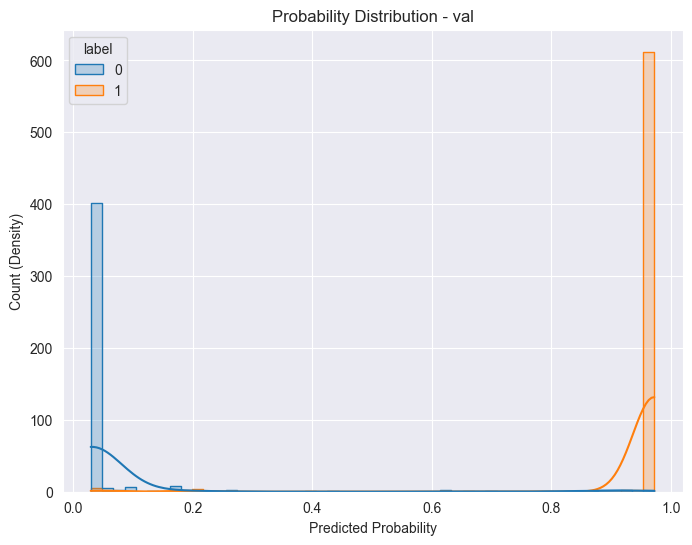

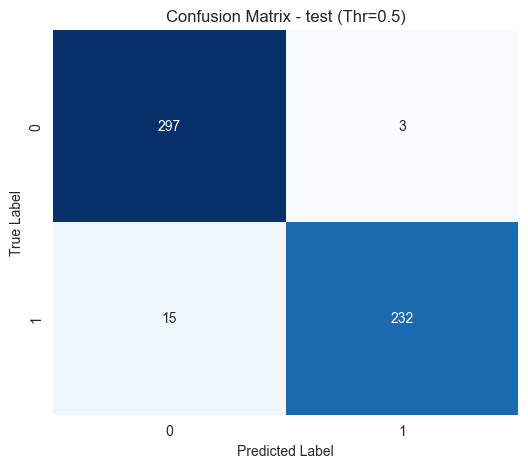

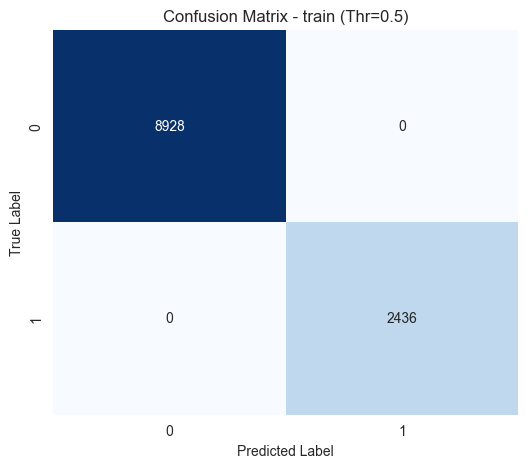

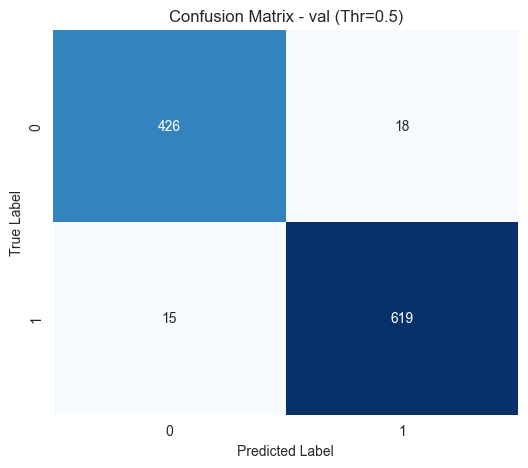

In [2]:
# 7. Visualization
print("\n--- Generating Plots ---")
# Load predictions (now with p_calib)
df_preds = pd.read_parquet(res.preds_path)

# Plot Raw
plot_roc_curves(df_preds, prob_col="p_raw", title="ROC Curves (Raw)")
plot_pr_curves(df_preds, prob_col="p_raw", title="PR Curves (Raw)")

# Plot Calibrated
if "p_calib" in df_preds.columns:
    plot_roc_curves(df_preds, prob_col="p_calib", title="ROC Curves (Calibrated)")
    plot_pr_curves(df_preds, prob_col="p_calib", title="PR Curves (Calibrated)")
    plot_probability_distributions(df_preds, prob_col="p_calib")
    plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)
